
LOADING DATASET

Dataset loaded successfully.

First 5 rows:
        RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type
0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0     1
1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0     1
2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0     1
3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0     1
4  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0     1

Dataset shape:
(214, 10)

Column names:
['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type']

DATA INFORMATION

Data types:
RI      float64
Na      float64
Mg      float64
Al      float64
Si      float64
K       float64
Ca      float64
Ba      float64
Fe      float64
Type      int64
dtype: object

Missing values:
RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

Duplicate rows:
1

Statistical summary:
               RI          Na          Mg          Al          Si    

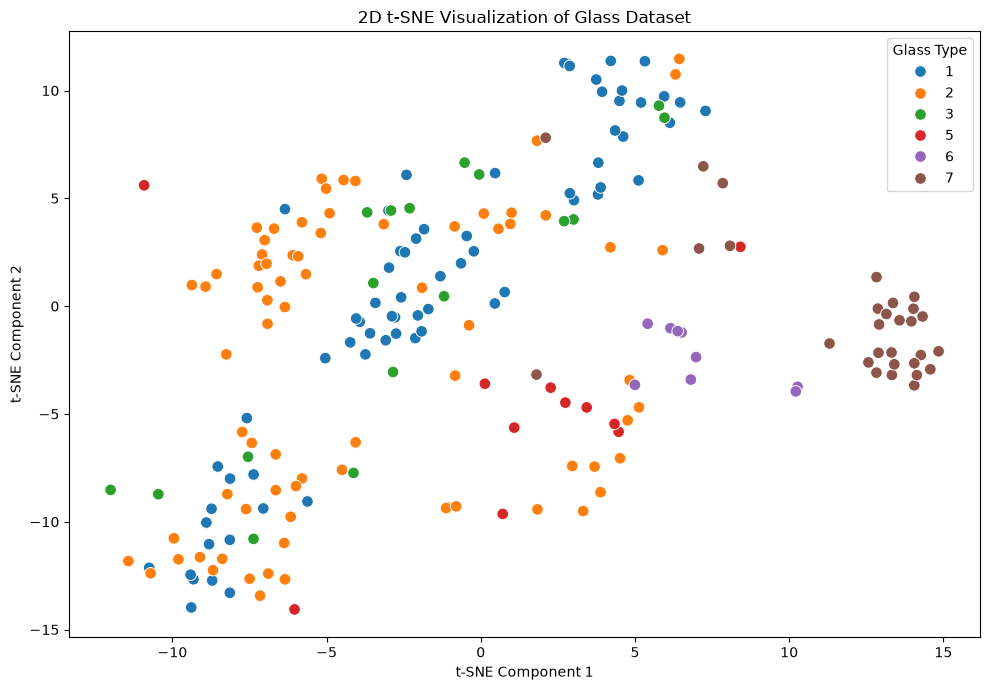

t-SNE plot saved as results/tsne_plot.png

----------------------------------------
SVM - Linear
----------------------------------------
Accuracy : 0.6977
Precision: 0.6635
Recall   : 0.6977
F1 Score : 0.6742
Execution Time: 0.011982 seconds

Confusion Matrix:
[[11  3  0  0  0  0]
 [ 5  9  0  0  1  0]
 [ 2  1  0  0  0  0]
 [ 0  0  0  3  0  0]
 [ 0  0  0  0  2  0]
 [ 0  1  0  0  0  5]]

Classification Report:
              precision    recall  f1-score   support

           1       0.61      0.79      0.69        14
           2       0.64      0.60      0.62        15
           3       0.00      0.00      0.00         3
           5       1.00      1.00      1.00         3
           6       0.67      1.00      0.80         2
           7       1.00      0.83      0.91         6

    accuracy                           0.70        43
   macro avg       0.65      0.70      0.67        43
weighted avg       0.66      0.70      0.67        43


----------------------------------------
SV

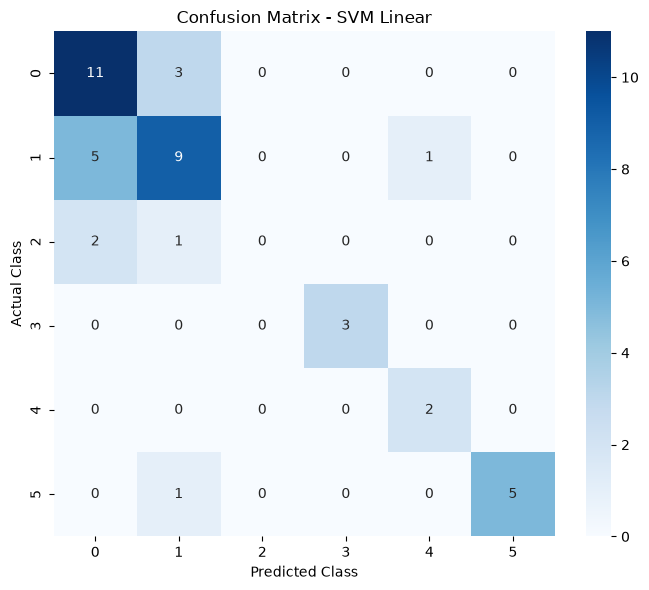

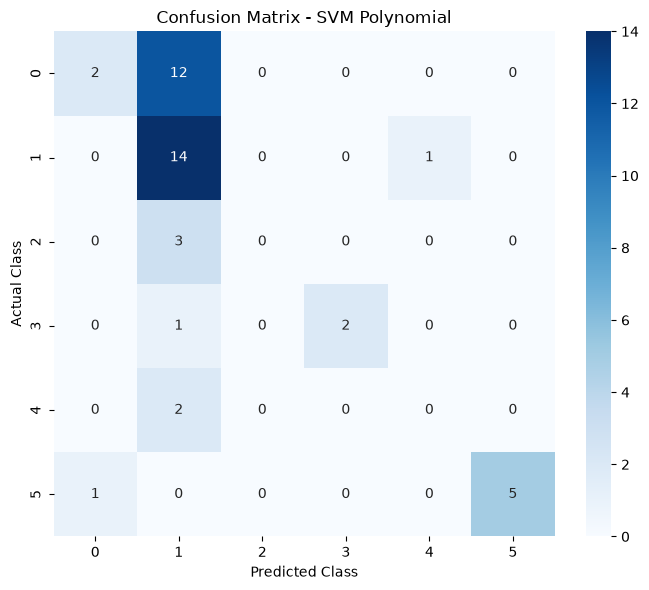

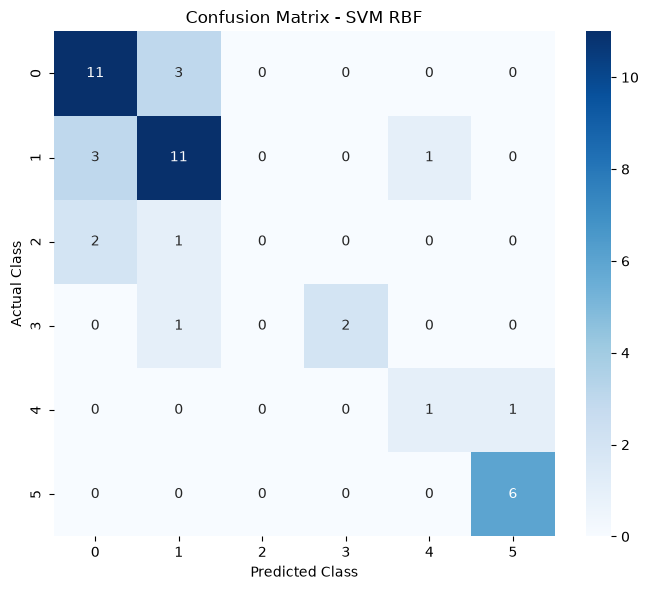

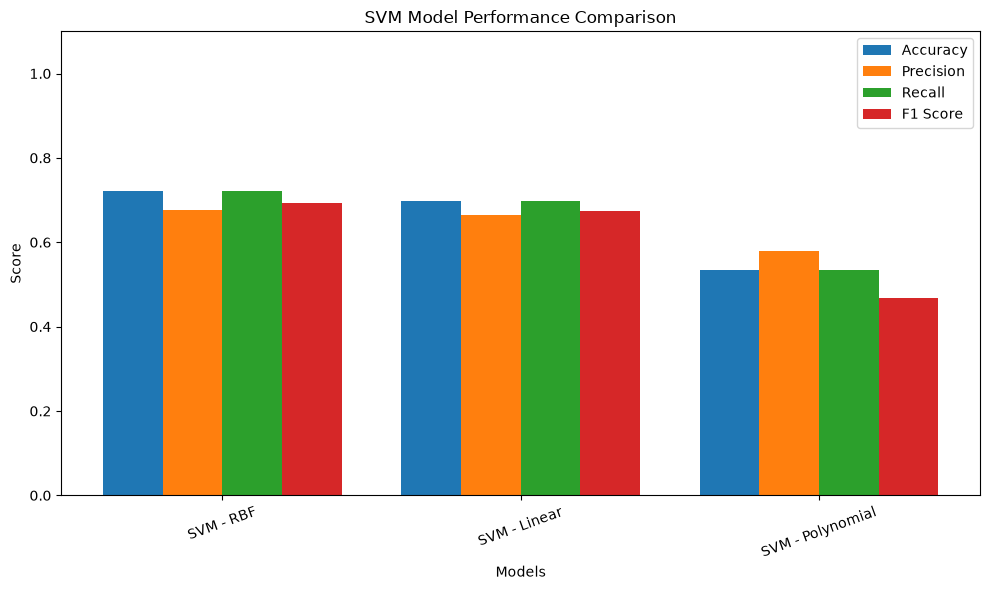

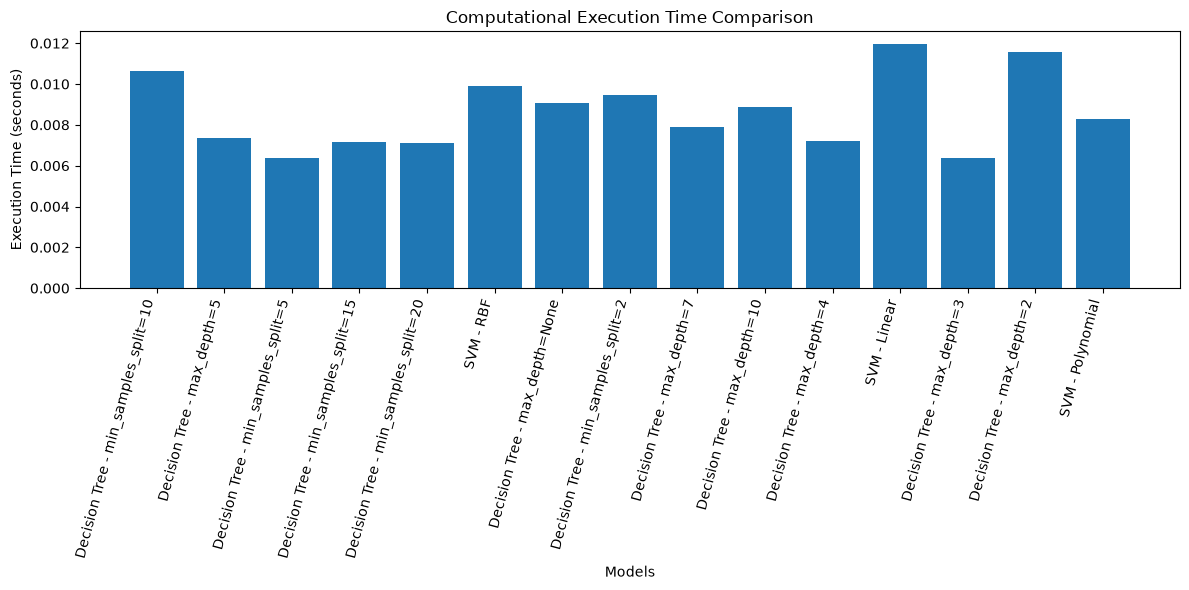


ASSIGNMENT 3 COMPLETED

Generated files:
1. results/tsne_plot.png
2. results/confusion_matrix_svm_linear.png
3. results/confusion_matrix_svm_poly.png
4. results/confusion_matrix_svm_rbf.png
5. results/svm_model_comparison.png
6. results/execution_time_comparison.png
7. results/model_comparison.csv

All models were trained and evaluated successfully.


In [1]:
# ============================================================
# ASSIGNMENT 3 - CLASSIFICATION
# Comparison of SVM and Decision Tree
# Dataset: Glass Classification
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")


# ------------------------------------------------------------
# 2. CREATE RESULTS FOLDER
# ------------------------------------------------------------

os.makedirs("results", exist_ok=True)


# ------------------------------------------------------------
# 3. LOAD DATASET
# ------------------------------------------------------------

print("\n========================================")
print("LOADING DATASET")
print("========================================")

file_path = "glass.csv"

df = pd.read_csv(file_path)

print("\nDataset loaded successfully.")

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())


# ------------------------------------------------------------
# 4. BASIC DATA INFORMATION
# ------------------------------------------------------------

print("\n========================================")
print("DATA INFORMATION")
print("========================================")

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nStatistical summary:")
print(df.describe())


# ------------------------------------------------------------
# 5. IDENTIFY TARGET COLUMN
# ------------------------------------------------------------

# The Kaggle Glass dataset normally uses "Type"
# If your CSV has a slightly different target name,
# change this variable.

target_column = "Type"

if target_column not in df.columns:

    # Try to find target automatically
    possible_targets = ["type", "Type", "class", "Class", "target", "Target"]

    found_target = None

    for col in possible_targets:
        if col in df.columns:
            found_target = col
            break

    if found_target is None:
        raise ValueError(
            "Target column not found. "
            "Please check your CSV column names."
        )

    target_column = found_target


print("\nTarget column:", target_column)


# ------------------------------------------------------------
# 6. REMOVE ID COLUMN
# ------------------------------------------------------------

# ID is not a useful predictive feature.
# It should not be included in model training.

id_columns = []

for col in df.columns:

    if col.lower() in ["id", "id_number", "id_number."]:
        id_columns.append(col)

if len(id_columns) > 0:

    print("\nRemoving ID column(s):", id_columns)

    df = df.drop(columns=id_columns)


# ------------------------------------------------------------
# 7. REMOVE MISSING VALUES
# ------------------------------------------------------------

df = df.dropna()

print("\nShape after removing missing values:")
print(df.shape)


# ------------------------------------------------------------
# 8. SEPARATE FEATURES AND TARGET
# ------------------------------------------------------------

X = df.drop(columns=[target_column])

y = df[target_column]

print("\n========================================")
print("FEATURES AND TARGET")
print("========================================")

print("\nFeature columns:")
print(X.columns.tolist())

print("\nNumber of features:", X.shape[1])

print("\nTarget classes:")
print(sorted(y.unique()))

print("\nClass distribution:")
print(y.value_counts().sort_index())


# ------------------------------------------------------------
# 9. MAKE SURE FEATURES ARE NUMERICAL
# ------------------------------------------------------------

print("\nFeature data types:")
print(X.dtypes)

# Convert features to numeric
X = X.apply(pd.to_numeric, errors="coerce")

# Remove rows generated as NaN after conversion
valid_rows = X.notnull().all(axis=1)

X = X.loc[valid_rows]
y = y.loc[valid_rows]


# ------------------------------------------------------------
# 10. TRAIN-TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n========================================")
print("TRAIN TEST SPLIT")
print("========================================")

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])


# ------------------------------------------------------------
# 11. STANDARDIZATION
# ------------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("\nFeature standardization completed.")


# ============================================================
# 12. 2D t-SNE VISUALIZATION
# ============================================================

print("\n========================================")
print("GENERATING 2D t-SNE PLOT")
print("========================================")

# Use complete standardized dataset for visualization

X_scaled = scaler.fit_transform(X)

# t-SNE perplexity must be smaller than number of samples

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    max_iter=1000
)

X_tsne = tsne.fit_transform(X_scaled)

tsne_df = pd.DataFrame(
    {
        "TSNE1": X_tsne[:, 0],
        "TSNE2": X_tsne[:, 1],
        "Class": y.values
    }
)

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=tsne_df,
    x="TSNE1",
    y="TSNE2",
    hue="Class",
    palette="tab10",
    s=70
)

plt.title("2D t-SNE Visualization of Glass Dataset")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Glass Type")
plt.tight_layout()

plt.savefig(
    "results/tsne_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("t-SNE plot saved as results/tsne_plot.png")


# ============================================================
# 13. FUNCTION FOR MODEL EVALUATION
# ============================================================

results = []


def evaluate_model(model, model_name, X_train_data,
                   X_test_data, y_train_data, y_test_data):

    print("\n----------------------------------------")
    print(model_name)
    print("----------------------------------------")

    # Start time
    start_time = time.perf_counter()

    # Train model
    model.fit(X_train_data, y_train_data)

    # Prediction
    y_pred = model.predict(X_test_data)

    # End time
    end_time = time.perf_counter()

    execution_time = end_time - start_time

    # Metrics
    accuracy = accuracy_score(y_test_data, y_pred)

    precision = precision_score(
        y_test_data,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test_data,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test_data,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))

    print("Execution Time:",
          round(execution_time, 6),
          "seconds")

    # Confusion matrix
    cm = confusion_matrix(y_test_data, y_pred)

    print("\nConfusion Matrix:")
    print(cm)

    # Classification report
    print("\nClassification Report:")
    print(
        classification_report(
            y_test_data,
            y_pred,
            zero_division=0
        )
    )

    # Store results
    results.append(
        {
            "Model": model_name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1_Score": f1,
            "Execution_Time_seconds": execution_time
        }
    )

    return model, y_pred, cm


# ============================================================
# 14. SVM - LINEAR KERNEL
# ============================================================

svm_linear = SVC(
    kernel="linear",
    random_state=42
)

model_linear, pred_linear, cm_linear = evaluate_model(
    svm_linear,
    "SVM - Linear",
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)


# ============================================================
# 15. SVM - POLYNOMIAL KERNEL
# ============================================================

svm_poly = SVC(
    kernel="poly",
    degree=3,
    random_state=42
)

model_poly, pred_poly, cm_poly = evaluate_model(
    svm_poly,
    "SVM - Polynomial",
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)


# ============================================================
# 16. SVM - RBF KERNEL
# ============================================================

svm_rbf = SVC(
    kernel="rbf",
    random_state=42
)

model_rbf, pred_rbf, cm_rbf = evaluate_model(
    svm_rbf,
    "SVM - RBF",
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)


# ============================================================
# 17. DECISION TREE - DIFFERENT MAX DEPTH
# ============================================================

print("\n========================================")
print("DECISION TREE - MAX DEPTH")
print("========================================")

depth_values = [2, 3, 4, 5, 7, 10, None]

for depth in depth_values:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    depth_name = f"Decision Tree - max_depth={depth}"

    evaluate_model(
        model,
        depth_name,
        X_train,
        X_test,
        y_train,
        y_test
    )


# ============================================================
# 18. DECISION TREE - DIFFERENT MIN SAMPLES SPLIT
# ============================================================

print("\n========================================")
print("DECISION TREE - MIN SAMPLES SPLIT")
print("========================================")

split_values = [2, 5, 10, 15, 20]

for split in split_values:

    model = DecisionTreeClassifier(
        min_samples_split=split,
        random_state=42
    )

    split_name = (
        f"Decision Tree - min_samples_split={split}"
    )

    evaluate_model(
        model,
        split_name,
        X_train,
        X_test,
        y_train,
        y_test
    )


# ============================================================
# 19. SAVE RESULTS
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1_Score",
    ascending=False
)

print("\n========================================")
print("FINAL MODEL COMPARISON")
print("========================================")

print(results_df.to_string(index=False))

results_df.to_csv(
    "results/model_comparison.csv",
    index=False
)

print(
    "\nResults saved as "
    "results/model_comparison.csv"
)


# ============================================================
# 20. CREATE CONFUSION MATRICES
# ============================================================

def save_confusion_matrix(cm, title, filename):

    plt.figure(figsize=(7, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(title)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")

    plt.tight_layout()

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


save_confusion_matrix(
    cm_linear,
    "Confusion Matrix - SVM Linear",
    "results/confusion_matrix_svm_linear.png"
)

save_confusion_matrix(
    cm_poly,
    "Confusion Matrix - SVM Polynomial",
    "results/confusion_matrix_svm_poly.png"
)

save_confusion_matrix(
    cm_rbf,
    "Confusion Matrix - SVM RBF",
    "results/confusion_matrix_svm_rbf.png"
)


# ============================================================
# 21. MODEL COMPARISON GRAPH
# ============================================================

# Select only main models for graph

main_models = results_df[
    results_df["Model"].isin(
        [
            "SVM - Linear",
            "SVM - Polynomial",
            "SVM - RBF"
        ]
    )
]

plt.figure(figsize=(10, 6))

x = np.arange(len(main_models))

width = 0.2

plt.bar(
    x - width,
    main_models["Accuracy"],
    width,
    label="Accuracy"
)

plt.bar(
    x,
    main_models["Precision"],
    width,
    label="Precision"
)

plt.bar(
    x + width,
    main_models["Recall"],
    width,
    label="Recall"
)

plt.bar(
    x + 2 * width,
    main_models["F1_Score"],
    width,
    label="F1 Score"
)

plt.xticks(
    x + width / 2,
    main_models["Model"],
    rotation=20
)

plt.ylim(0, 1.1)

plt.ylabel("Score")

plt.xlabel("Models")

plt.title("SVM Model Performance Comparison")

plt.legend()

plt.tight_layout()

plt.savefig(
    "results/svm_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 22. EXECUTION TIME COMPARISON
# ============================================================

plt.figure(figsize=(12, 6))

plt.bar(
    results_df["Model"],
    results_df["Execution_Time_seconds"]
)

plt.xticks(
    rotation=75,
    ha="right"
)

plt.ylabel("Execution Time (seconds)")

plt.xlabel("Models")

plt.title("Computational Execution Time Comparison")

plt.tight_layout()

plt.savefig(
    "results/execution_time_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 23. FINAL MESSAGE
# ============================================================

print("\n========================================")
print("ASSIGNMENT 3 COMPLETED")
print("========================================")

print("\nGenerated files:")

print("1. results/tsne_plot.png")
print("2. results/confusion_matrix_svm_linear.png")
print("3. results/confusion_matrix_svm_poly.png")
print("4. results/confusion_matrix_svm_rbf.png")
print("5. results/svm_model_comparison.png")
print("6. results/execution_time_comparison.png")
print("7. results/model_comparison.csv")

print("\nAll models were trained and evaluated successfully.")